In [3]:
import numpy as np
import pandas as pd
from sklearn import metrics
from openpyxl import load_workbook
from sklearn.tree import export_graphviz
from sklearn.ensemble import RandomForestRegressor
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import multiprocessing
import os
import time
import gloce as gc
from osgeo import gdal
from osgeo import gdalconst
from mpl_toolkits.basemap import Basemap
from glob import glob
from math import ceil
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
#return im_data, im_width, im_height, im_geotrans, im_proj
def read_img(filename):
    dt = gdal.Open(filename)
    im_width = dt.RasterXSize
    im_height = dt.RasterYSize
    im_bands = dt.RasterCount
    im_geotrans = dt.GetGeoTransform()
    im_proj = dt.GetProjection()
    im_data = dt.ReadAsArray(0,0,im_width,im_height)
    return im_data, im_width, im_height, im_geotrans, im_proj
def write_img(filename, im_proj, im_geotrans, im_data):
    if 'int8' in im_data.dtype.name:
        datatype = gdal.GDT_Byte
    elif 'int16' in im_data.dtype.name:
        datatype = gdal.GDT_UInt16
    else:
        datatype = gdal.GDT_Float32
    if len(im_data.shape) == 3:
        im_bands, im_height, im_width = im_data.shape
    else:
        im_bands, (im_height, im_width) = 1, im_data.shape
    driver = gdal.GetDriverByName("GTiff")
    dataset = driver.Create(filename, im_width, im_height, im_bands, datatype)
    dataset.SetGeoTransform(im_geotrans)
    dataset.SetProjection(im_proj)
    if im_bands == 1:
        dataset.GetRasterBand(1).WriteArray(im_data)
    else:
        for i in range(im_bands):
            dataset.GetRasterBand(i + 1).WriteArray(im_data[i])
spei_path='//weili/User2/mxsun/CESS_230818/SPEI_highRes/'
sm_path='//weili/User2/mxsun/CESS_230818/SPEI_highRes/RF/'
soil_path='//weili/User2/mxsun/CESS_230818/SPEI_highRes/RF/'
drv_path='//weili/User2/mxsun/CESS_230818/Pattern_drive/'
ele_path='//weili/User2/mxsun/CESS_230818/elephant_active_area/IUCN/'

# Partial correlation

## 数据准备

In [17]:
#---------------------------单年份data----------------------------------
#-----vegetation-----
treeH = read_img(spei_path+'African_th2019_001_230525.tif')[0]
tc = read_img(spei_path+'Africa_tc2019_mosaic_001_fillNaN_231215.tif')[0]#Planet TC,用Hansen TC填补空缺值
treeH[treeH==0]=np.nan
tc=tc.astype(np.float32)
tc[tc==0]=np.nan
tc[tc>100]=np.nan

lst=read_img(spei_path+'lst_1516_afr_001.tif')[0]
lst=lst*0.02-273.15
tc=tc.astype(np.float32)
tc[tc==0]=np.nan
tc[tc>100]=np.nan

In [18]:
spei=read_img(spei_path+'SPEI_yrMean_afr_1516_001_sub.tif')[0]
spei[spei==0]=np.nan

In [20]:
ndvi_res=read_img(spei_path+'ndvi_resistance_230321.tif')[0]
csif_res=read_img(spei_path+'csif_resistance_230321.tif')[0]
ndvi_res[ndvi_res==0]=np.nan
csif_res[csif_res==0]=np.nan

In [22]:
dem=read_img(spei_path+'gtopoDEM_afr_001.tif')[0]
slope=read_img(spei_path+'gtopoSlope_afr_001.tif')[0]
dem=dem.astype(np.float32)
dem[dem==-9999]=np.nan
slope[slope==0]=np.nan

In [24]:
#mask匹配所有有效像素，以保证paired sites所有变量的分析区域一致
mask_pixel=ndvi_res*csif_res*treeH*tc*lst*dem*slope*spei
mask_pixel[~np.isnan(mask_pixel)]=1
np.count_nonzero(~np.isnan(mask_pixel))

8199493

In [25]:
DEAA=read_img(spei_path+'SPEI_deaa001_240504.tif')[0]
DAA=read_img(spei_path+'SPEI_daa001_240504.tif')[0]
DEAA[DEAA==0]=np.nan
DAA[DAA==0]=np.nan

In [26]:
hfp = read_img(spei_path+'hfp2018_Afirca_001_230525.tif')[0]
hfp[hfp<=15]=1
hfp[hfp>1]=np.nan

In [27]:
mask=hfp*mask_pixel
mask[~np.isnan(mask)]=1
np.nanmin(mask),np.nanmax(mask)

(1.0, 1.0)

## slide window

In [28]:
"""
supply paired sites methods. 
Be notes the  suppled detail locates should be consistence with all factors.
"""
# current shape:(6500,7900)
#0.01deg to 0.25 deg window size=625 pixels
#6500/25,7900/25...(260,316)
def slide_window_mean(s,dist,res):
    #s: window size
    #dist: disturb array
    #res: resistance and resilience array
    mean_arr=np.zeros((260,316))
    weight_arr=np.zeros((260,316))
    loc=np.zeros((260,316)) #record the location of supplied sites
    sl=np.ones((25,25))
    for i in range(260):
        #print("sliding", i, "line...")
        for j in range(316):
            bloc_dist=dist[i*s:(i+1)*s,j*s:(j+1)*s]
            res_dist=res[i*s:(i+1)*s,j*s:(j+1)*s]
            res_mask=np.multiply(bloc_dist,res_dist)#product restance array controled by window
            count=np.count_nonzero(~np.isnan(res_mask))
            weight=count/625#calculate the weight
            if weight>0.05:
                weight_arr[i,j]=weight
                dt=np.where(res_mask!=np.nan,res_mask,np.nan)
                mean_arr[i,j]=np.nanmean(res_mask)#calculate the mean value
                loc[i,j]=9
            else:
                bloc_dist_a=[] #should be 8 nums [-1,0],[0,-1],[-1,-1],[1,0],[0,1],[1,1],[-1,1],[1,-1]
                res_dist_a=[] #should be 8 nums
                res_mask_pool=[]
                weight_pool=[]
                for m in [-1,1]:
                    bloc_dist_a.append(dist[(i+m)*s:((i+m)+1)*s,j*s:(j+1)*s])
                    bloc_dist_a.append(dist[i*s:(i+1)*s,(j+m)*s:((j+m)+1)*s])
                    bloc_dist_a.append(dist[(i+m)*s:((i+m)+1)*s,(j+m)*s:((j+m)+1)*s])
                    res_dist_a.append(res[(i+m)*s:((i+m)+1)*s,j*s:(j+1)*s])
                    res_dist_a.append(res[i*s:(i+1)*s,(j+m)*s:((j+m)+1)*s])
                    res_dist_a.append(res[(i+m)*s:((i+m)+1)*s,(j+m)*s:((j+m)+1)*s])
                bloc_dist_a.append(dist[(i-1)*s:((i-1)+1)*s,(j+1)*s:((j+1)+1)*s])
                bloc_dist_a.append(dist[(i+1)*s:((i+1)+1)*s,(j-1)*s:((j-1)+1)*s])
                res_dist_a.append(res[(i-1)*s:((i-1)+1)*s,(j+1)*s:((j+1)+1)*s])
                res_dist_a.append(res[(i+1)*s:((i+1)+1)*s,(j-1)*s:((j-1)+1)*s])
                #the smooth order of a 9 value array is [-1,0],[0,-1],[-1,-1],[1,0],[0,1],[1,1],[-1,1],[1,-1]
                for n in range(len(bloc_dist_a)): #the length is 8
                    res_mask_pool.append(np.multiply(bloc_dist_a[n],res_dist_a[n]))
                    weight_pool.append(np.count_nonzero(~np.isnan(res_mask_pool[n]))/625)#calculate the weight
                key=np.argmax(weight_pool)
                # Key used to loc the supplied direction, the key-value consistience with [-1,0],[0,-1],[-1,-1],[1,0],[0,1],[1,1],[-1,1],[1,-1]
                if weight_pool[key] > 0.05:
                    weight_arr[i,j]=weight_pool[key]
                    dt1=np.where(res_mask_pool[key]!=np.nan,res_mask_pool[key],np.nan)
                    mean_arr[i,j]=np.nanmean(dt1)#calculate the mean value
                    loc[i,j]=key+1
                else:
                    mean_arr[i,j]=np.nan#calculate the mean value
                    loc[i,j]=np.nan
    return mean_arr

dist_pool=[DEAA*mask,DAA*mask]
res_pool=[ndvi_res,csif_res,treeH,tc,lst,spei,dem,slope] #protect need conver to fraction
dist_name=['DEAA','DAA']
res_name=['ndvi_res','csif_res','th','tc','lst','spei','dem','slope']
# protect 最后直接加上去
aa=[]
aa_name=[]
for i in range(2):
    for j in range(8):
        el=[25,dist_pool[i],res_pool[j]]
        aa.append(el)
        aa_name.append('pathways_{}_{}_0.25deg_250312.npy'.format(dist_name[i],res_name[j]))
aa_name

['pathways_DEAA_ndvi_res_0.25deg_250312.npy',
 'pathways_DEAA_csif_res_0.25deg_250312.npy',
 'pathways_DEAA_th_0.25deg_250312.npy',
 'pathways_DEAA_tc_0.25deg_250312.npy',
 'pathways_DEAA_lst_0.25deg_250312.npy',
 'pathways_DEAA_spei_0.25deg_250312.npy',
 'pathways_DEAA_dem_0.25deg_250312.npy',
 'pathways_DEAA_slope_0.25deg_250312.npy',
 'pathways_DAA_ndvi_res_0.25deg_250312.npy',
 'pathways_DAA_csif_res_0.25deg_250312.npy',
 'pathways_DAA_th_0.25deg_250312.npy',
 'pathways_DAA_tc_0.25deg_250312.npy',
 'pathways_DAA_lst_0.25deg_250312.npy',
 'pathways_DAA_spei_0.25deg_250312.npy',
 'pathways_DAA_dem_0.25deg_250312.npy',
 'pathways_DAA_slope_0.25deg_250312.npy']

In [29]:
for i in range(16):
    print('执行任务%s (%s)...' % (i, os.getpid()))
    kk=slide_window_mean(aa[i][0],aa[i][1],aa[i][2])
    np.save(drv_path+aa_name[i],kk)

执行任务0 (44156)...
执行任务1 (44156)...
执行任务2 (44156)...
执行任务3 (44156)...
执行任务4 (44156)...
执行任务5 (44156)...
执行任务6 (44156)...
执行任务7 (44156)...
执行任务8 (44156)...
执行任务9 (44156)...
执行任务10 (44156)...
执行任务11 (44156)...
执行任务12 (44156)...
执行任务13 (44156)...
执行任务14 (44156)...
执行任务15 (44156)...


In [30]:
#--------------------elephant density---------------------------------------
# check the Δ dem and Δ slope distribution
dem1=np.load(drv_path+'pathways_DEAA_dem_0.25deg_250312.npy',allow_pickle=True)
dem2=np.load(drv_path+'pathways_DAA_dem_0.25deg_250312.npy',allow_pickle=True)
dem_differ=dem1-dem2

slo1=np.load(drv_path+'pathways_DEAA_slope_0.25deg_250312.npy',allow_pickle=True)
slo2=np.load(drv_path+'pathways_DAA_slope_0.25deg_250312.npy',allow_pickle=True)
slo_differ=slo1-slo2

dem_differ[dem_differ<-200]=np.nan
dem_differ[dem_differ>200]=np.nan
dem_differ[~np.isnan(dem_differ)]=1
slo_differ[slo_differ<-10]=np.nan
slo_differ[slo_differ>10]=np.nan
slo_differ[~np.isnan(slo_differ)]=1
# 每一层数据位置对应,建立mask
dd_mask=np.ones((260,316))*dem_differ*slo_differ

# Add mean paras
res_name=['ndvi_res','csif_res']

mm=[]#干旱导致ndvi和sif下降的格点mask
res_delta=[]
for i in range(2):
    f1=np.load(drv_path+'pathways_DEAA_{}_0.25deg_250312.npy'.format(res_name[i]),allow_pickle=True)*dd_mask
    f2=np.load(drv_path+'pathways_DAA_{}_0.25deg_250312.npy'.format(res_name[i]),allow_pickle=True)*dd_mask
    ff=f1-f2
    print(np.count_nonzero(~np.isnan(ff)))
    tt=f2
    tt[tt>1]=np.nan
    tt[tt<=1]=1
    mm.append(tt)
    res_delta.append(ff*tt)
    print(np.count_nonzero(~np.isnan(tt)))

2631
1496
2631
1931


In [34]:
other_name=['th','tc','lst','spei']
delta_ndvi_reduc=[res_delta[0]]
delta_sif_reduc=[res_delta[1]]
for i in range(4):
    if i<3:
        f1=np.load(drv_path+'pathways_DEAA_{}_0.25deg_250312.npy'.format(other_name[i]),allow_pickle=True)*dd_mask
        f2=np.load(drv_path+'pathways_DAA_{}_0.25deg_250312.npy'.format(other_name[i]),allow_pickle=True)*dd_mask
        ff=f1-f2
        delta_ndvi_reduc.append(ff*mm[0])
        delta_sif_reduc.append(ff*mm[1])
    else:
        f1=np.load(drv_path+'pathways_DEAA_{}_0.25deg_250312.npy'.format(other_name[i]),allow_pickle=True)*dd_mask
        f2=np.load(drv_path+'pathways_DAA_{}_0.25deg_250312.npy'.format(other_name[i]),allow_pickle=True)*dd_mask
        ff=(f1+f2)/2
        delta_ndvi_reduc.append(ff*mm[0])
        delta_sif_reduc.append(ff*mm[1])

In [35]:
len(delta_ndvi_reduc),len(delta_sif_reduc)

(5, 5)

In [36]:
#每一层数据位置对应，建立mask,使得每一层有效数值位置对应
dd_ndvi=np.copy(delta_ndvi_reduc)
dd_ndvi[~np.isnan(dd_ndvi)]=1
cc_mask_ndvi=np.ones((260,316))

dd_sif=np.copy(delta_sif_reduc)
dd_sif[~np.isnan(dd_sif)]=1
cc_mask_sif=np.ones((260,316))
for i in range(5):
    cc_mask_ndvi=cc_mask_ndvi*dd_ndvi[i]
    cc_mask_sif=cc_mask_sif*dd_sif[i]

delta_dd_ndvi_reduc=np.copy(delta_ndvi_reduc)
delta_dd_sif_reduc=np.copy(delta_sif_reduc)
for i in range(5):
    delta_dd_ndvi_reduc[i]=delta_ndvi_reduc[i]*cc_mask_ndvi
    delta_dd_sif_reduc[i]=delta_sif_reduc[i]*cc_mask_sif
    print(np.count_nonzero(~np.isnan(delta_dd_ndvi_reduc[i])))
    print(np.count_nonzero(~np.isnan(delta_dd_sif_reduc[i])))

1496
1931
1496
1931
1496
1931
1496
1931
1496
1931


In [45]:
def kill_nan(dt):
    a=dt.ravel()
    a=a[~np.isnan(a)]
    a=list(a)
    return a

pd_delta_ndvi=[]
for i in range(5):
    pd_delta_ndvi.append(kill_nan(delta_dd_ndvi_reduc[i]))

pd_delta_ndvi=list(map(list, zip(*pd_delta_ndvi)))#list转置
df_ndvi=pd.DataFrame(pd_delta_ndvi,columns=['NDVI_res','TH','TC','LST','SPEI_m'])
df_ndvi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1496 entries, 0 to 1495
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   NDVI_res  1496 non-null   float64
 1   TH        1496 non-null   float64
 2   TC        1496 non-null   float64
 3   LST       1496 non-null   float64
 4   SPEI_m    1496 non-null   float64
dtypes: float64(5)
memory usage: 58.6 KB


In [47]:
pd_delta_sif=[]
for i in range(5):
    pd_delta_sif.append(kill_nan(delta_dd_sif_reduc[i]))

pd_delta_sif=list(map(list, zip(*pd_delta_sif)))#list转置
df_sif=pd.DataFrame(pd_delta_sif,columns=['SIF_res','TH','TC','LST','SPEI_m'])
df_sif.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1931 entries, 0 to 1930
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   SIF_res  1931 non-null   float64
 1   TH       1931 non-null   float64
 2   TC       1931 non-null   float64
 3   LST      1931 non-null   float64
 4   SPEI_m   1931 non-null   float64
dtypes: float64(5)
memory usage: 75.6 KB


In [48]:
#回归残差求偏相关系数
import statsmodels.api as sm
from statsmodels.formula.api import ols
#control=['SPEI','Precipitation',['SPEI','Precipitation'],'dif_LST',['dif_LST','SPEI'],['dif_LST','Precipitation'],['dif_LST','SPEI','Precipitation']]
#控制变量LST
th_lst_ndvi=sm.OLS(df_ndvi['TH'],df_ndvi['LST']).fit()
tc_lst_ndvi=sm.OLS(df_ndvi['TC'],df_ndvi['LST']).fit()
NDVIres_lst=sm.OLS(df_ndvi['NDVI_res'],df_ndvi['LST']).fit()

In [49]:
th_lst_sif=sm.OLS(df_sif['TH'],df_sif['LST']).fit()
tc_lst_sif=sm.OLS(df_sif['TC'],df_sif['LST']).fit()
SIFres_lst=sm.OLS(df_sif['SIF_res'],df_sif['LST']).fit()

In [50]:
res_tree_ndvi=[df_ndvi['TH'],th_lst_ndvi.resid,df_ndvi['TC'],tc_lst_ndvi.resid]
res_tree_sif=[df_sif['TH'],th_lst_sif.resid,df_sif['TC'],tc_lst_sif.resid]
res_res=[df_ndvi['NDVI_res'],df_sif['SIF_res']]
res_redius=[NDVIres_lst.resid,SIFres_lst.resid]

In [51]:
res_tree=[res_tree_ndvi,res_tree_sif]

## fig

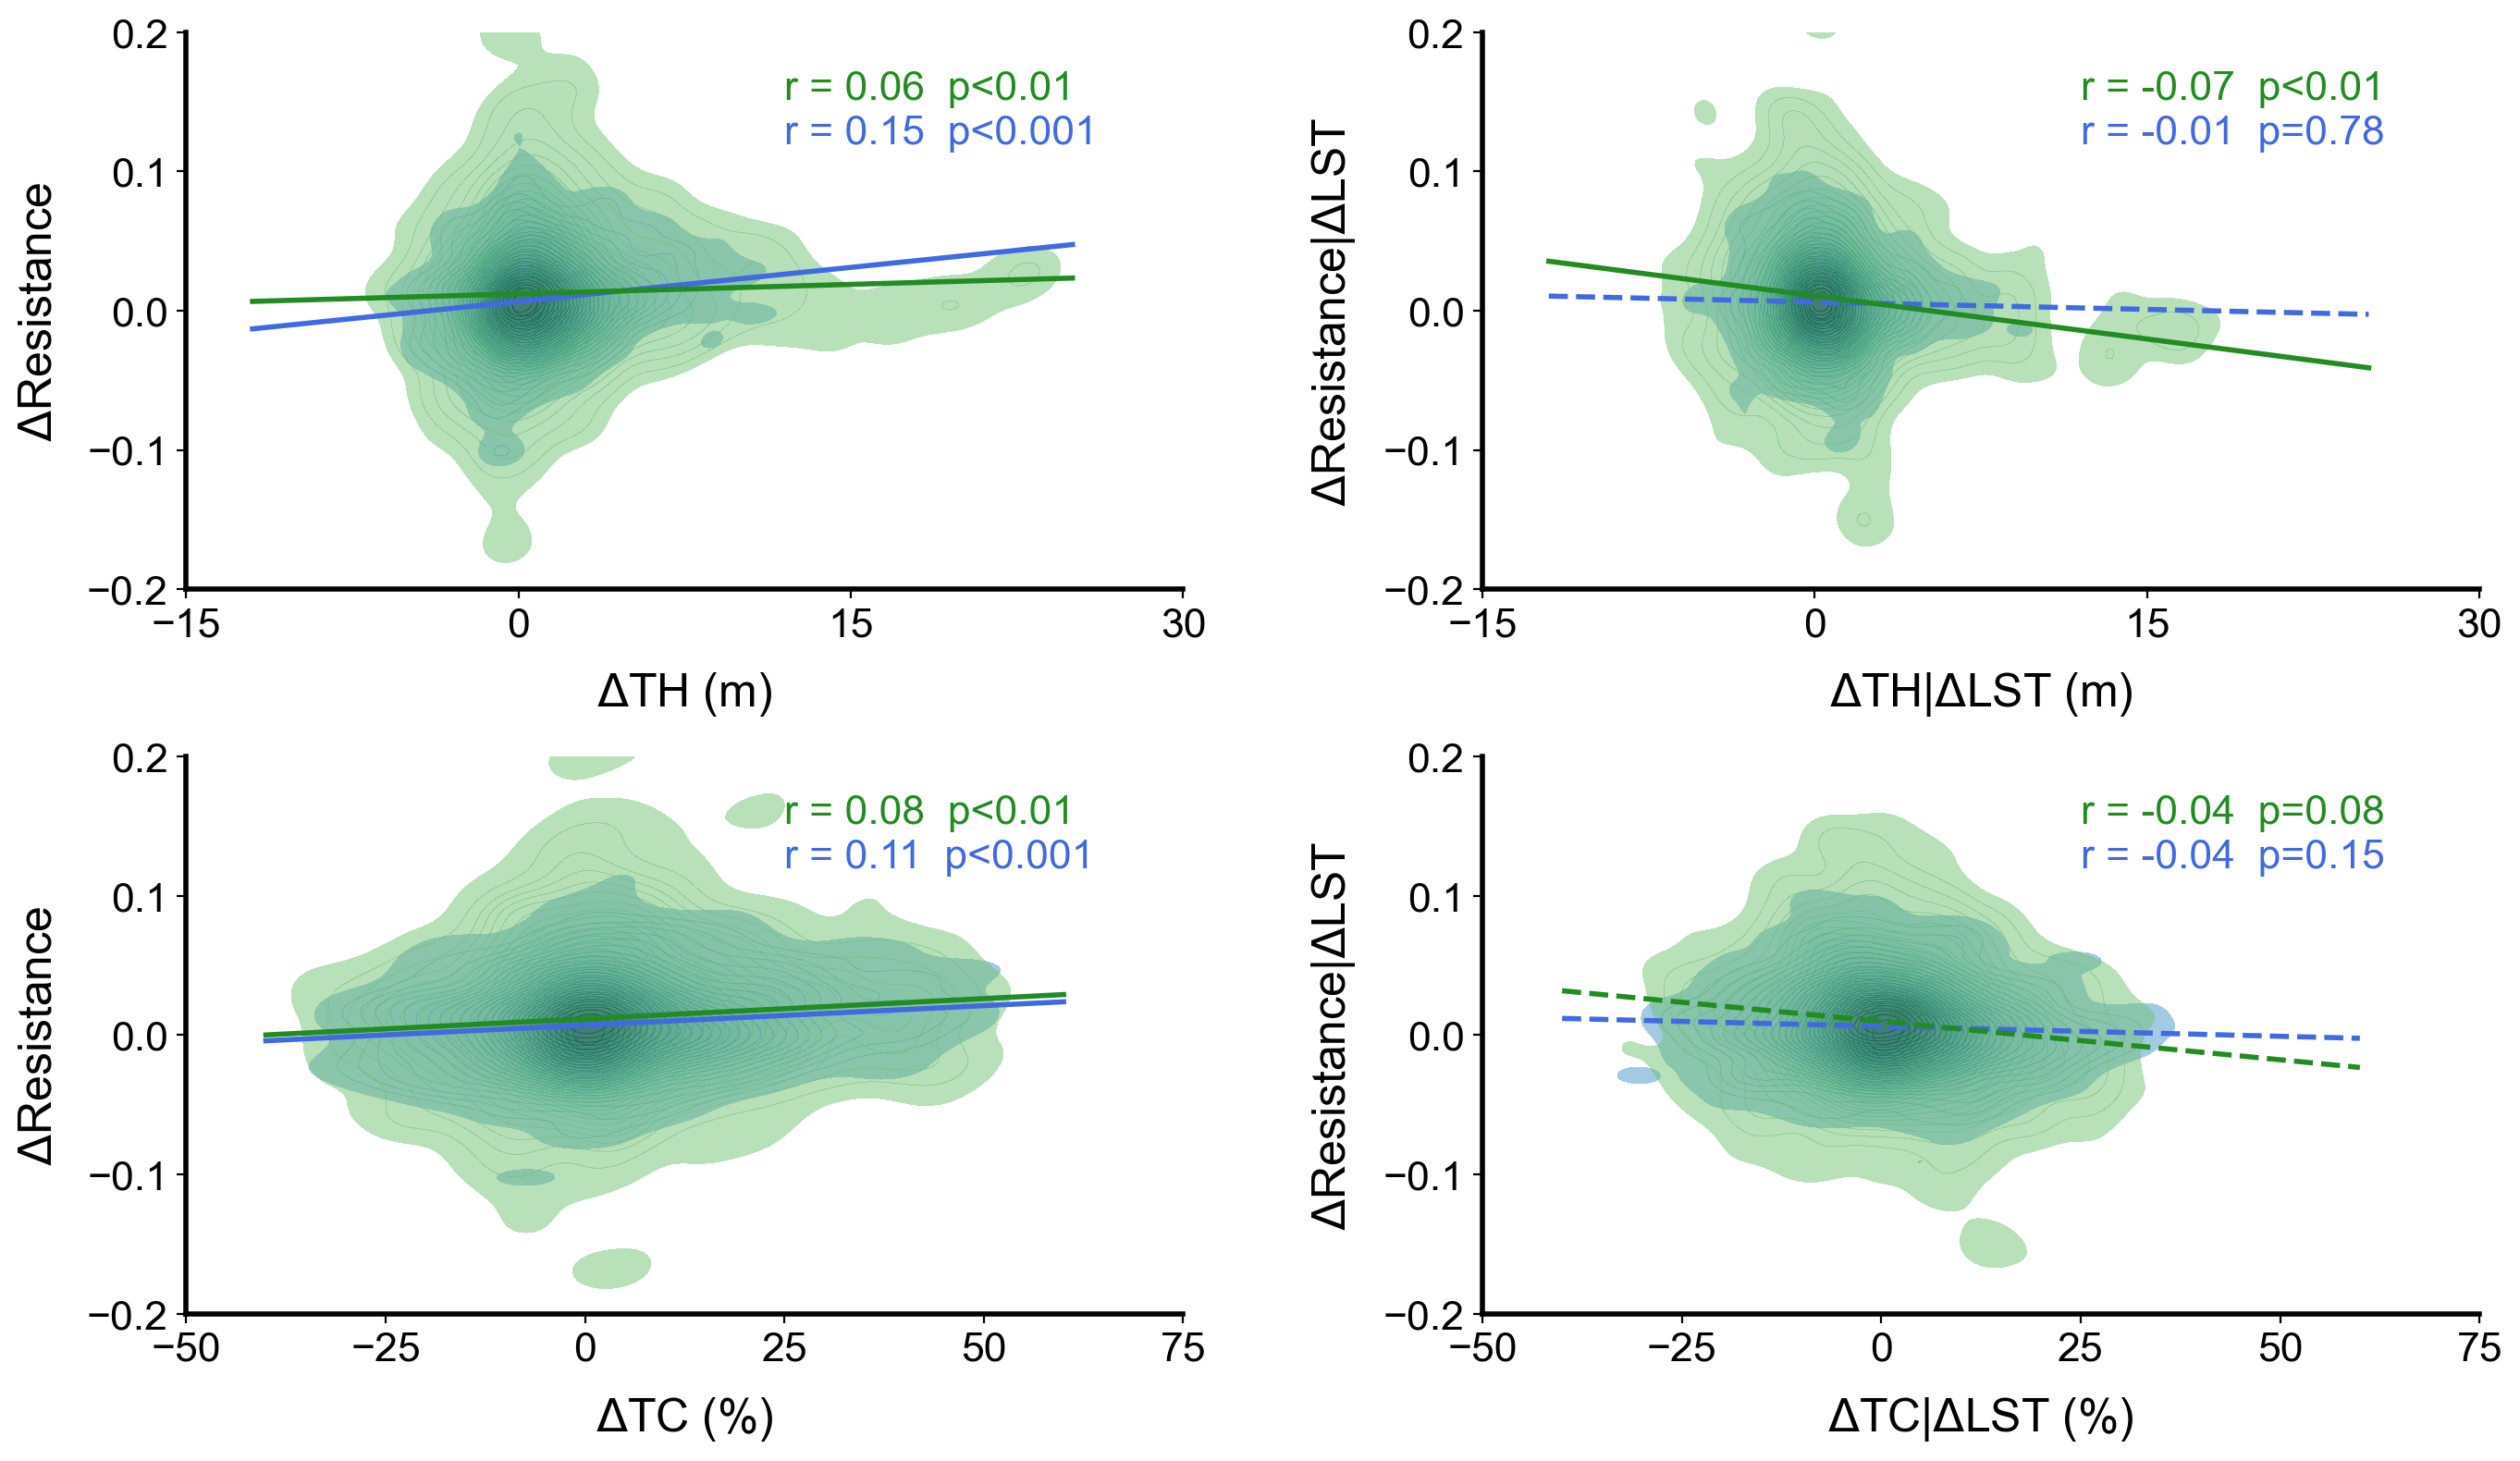

In [52]:
import scipy
import matplotlib.pyplot as plt
import pingouin as pg
import seaborn as sns
import matplotlib.colors as colors
from scipy.stats import gaussian_kde
from sklearn.metrics import r2_score
from matplotlib.gridspec import GridSpec     # 利用网格确定图形的位置
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
fig = plt.figure(figsize=(16,9)) ##width, height default(8,6)
fig.subplots_adjust(wspace=0.3,hspace=0.3, left=None, bottom=None, right=None, top=None)
font = {'family': 'sans-serif',
        'sans-serif': 'Arial',
        'weight': 'normal',
        'size': 16}
plt.rc('font', **font)  # pass in the font dict as kwargs

cl=['royalblue','forestgreen']
mark=['*','.']
lab_x=['$Δ$TH (m)','$Δ$TH|$Δ$LST (m)','$Δ$TC (%)','$Δ$TC|$Δ$LST (%)']
lab_y=['$Δ$Resistance','$Δ$Resistance|$Δ$LST','$Δ$Resistance','$Δ$Resistance|$Δ$LST']
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        "trunc({n},{a:.2f},{b:.2f})".format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap
trunc_cmap = [truncate_colormap(plt.get_cmap("Blues"), 0.6, 1),truncate_colormap(plt.get_cmap("Greens"), 0.5, 0.9)]
cov=[[],'LST',[],'LST']
x_a=['TH','TH','TC','TC']
y_a=['NDVI_res','SIF_res']

for i in range(4):
    ax=fig.add_subplot(2,2,i+1)
    if i<=1:
        xx=np.linspace(-12,25,1000)
        ax.set_ylim(-0.2,0.2)
        ax.set_yticks(np.arange(-0.2,0.201,0.1))
        ax.set_xlim(-15,30)
        ax.set_xticks(np.arange(-15,30.1,15))
    else:
        xx=np.linspace(-40,60,1000)
        ax.set_ylim(-0.2,0.2)
        ax.set_yticks(np.arange(-0.2,0.201,0.1))
        ax.set_xlim(-50,75)
        ax.set_xticks(np.arange(-50,75.1,25))
    if i==0 or i==2:
        for j in range(2):
            kde_plot = sns.kdeplot(x=res_tree[j][i], y=res_res[j], cmap=trunc_cmap[j], alpha=0.5,fill=True,ax=ax,levels=30, thresh=0.04)
            poly=np.polyfit(x=res_tree[j][i], y=res_res[j],deg=1)#一元二次方程拟合,,w=count[i]
            y_value=np.polyval(poly,xx)
            #yfit=np.polyval(poly,res_res[j])
            if j==0:
                cor=df_ndvi.partial_corr(x=x_a[i],y=y_a[j],covar=cov[i],method='spearman').round(3)['r']
                p_value=df_ndvi.partial_corr(x=x_a[i],y=y_a[j],covar=cov[i],method='spearman').round(3)['p-val']
            else:
                cor=df_sif.partial_corr(x=x_a[i],y=y_a[j],covar=cov[i],method='spearman').round(3)['r']
                p_value=df_sif.partial_corr(x=x_a[i],y=y_a[j],covar=cov[i],method='spearman').round(3)['p-val']
            if p_value[0]<0.001:
                ax.plot(xx,y_value,color=cl[j],linewidth=2)
                ax.text(0.6,0.8+0.08*j,'r = {:.2f}  p<0.001'.format(cor[0]), transform = ax.transAxes,color=cl[j])
            elif p_value[0]<0.01:
                ax.plot(xx,y_value,color=cl[j],linewidth=2)
                ax.text(0.6,0.8+0.08*j,'r = {:.2f}  p<0.01'.format(cor[0]), transform = ax.transAxes,color=cl[j])
            elif p_value[0]<0.05:
                ax.plot(xx,y_value,color=cl[j],linewidth=2)
                ax.text(0.6,0.8+0.08*j,'r = {:.2f}  p<0.05'.format(cor[0]), transform = ax.transAxes,color=cl[j])
            elif p_value[0]>=0.05:
                ax.plot(xx,y_value,color=cl[j],linestyle='--',linewidth=2)
                ax.text(0.6,0.8+0.08*j,'r = {:.2f}  p={:.2f}'.format(cor[0],p_value[0]), transform = ax.transAxes,color=cl[j])
    if i==1 or i==3:
        for j in range(2):
            kde_plot1 = sns.kdeplot(x=res_tree[j][i], y=res_redius[j], cmap=trunc_cmap[j], alpha=0.5,fill=True,ax=ax,levels=30, thresh=0.04)
            poly1=np.polyfit(x=res_tree[j][i], y=res_redius[j],deg=1)#一元二次方程拟合,,w=count[i]
            y_value1=np.polyval(poly1,xx)
            #yfit1=np.polyval(poly1,res_redius[j])
            if j==0:
                cor=df_ndvi.partial_corr(x=x_a[i],y=y_a[j],covar=cov[i],method='spearman').round(3)['r']
                p_value=df_ndvi.partial_corr(x=x_a[i],y=y_a[j],covar=cov[i],method='spearman').round(3)['p-val']
            else:
                cor=df_sif.partial_corr(x=x_a[i],y=y_a[j],covar=cov[i],method='spearman').round(3)['r']
                p_value=df_sif.partial_corr(x=x_a[i],y=y_a[j],covar=cov[i],method='spearman').round(3)['p-val']
            #cor1,p_value1 = scipy.stats.spearmanr(res_tree[i],res_redius[j])
            if p_value[0]<0.001:
                ax.plot(xx,y_value1,color=cl[j],linewidth=2)
                #cor,p_value = scipy.stats.spearmanr(res_tree[i],res_res[j])
                ax.text(0.6,0.8+0.08*j,'r = {:.2f}  p<0.001'.format(cor[0]), transform = ax.transAxes,color=cl[j])
            elif p_value[0]<0.01:
                ax.plot(xx,y_value1,color=cl[j],linewidth=2)
                #cor,p_value = scipy.stats.spearmanr(res_tree[i],res_res[j])
                ax.text(0.6,0.8+0.08*j,'r = {:.2f}  p<0.01'.format(cor[0]), transform = ax.transAxes,color=cl[j])
            elif p_value[0]<0.05:
                ax.plot(xx,y_value1,color=cl[j],linewidth=2)
                #cor,p_value = scipy.stats.spearmanr(res_tree[i],res_res[j])
                ax.text(0.6,0.8+0.08*j,'r = {:.2f}  p<0.05'.format(cor[0]), transform = ax.transAxes,color=cl[j])
            elif p_value[0]>=0.05:
                ax.plot(xx,y_value1,color=cl[j],linestyle='--',linewidth=2)
                #cor,p_value = scipy.stats.spearmanr(res_tree[i],res_res[j])
                ax.text(0.6,0.8+0.08*j,'r = {:.2f}  p={:.2f}'.format(cor[0],p_value[0]), transform = ax.transAxes,color=cl[j])
    
    ax.set_xlabel(lab_x[i],size=18,labelpad=10)
    ax.set_ylabel(lab_y[i],size=18,labelpad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
#fig.savefig("E:/iCloudDrive/博后工作/文章/Elephant_disturb/Fig/ReviseV4/Fig4a_d.tif", dpi=600, bbox_inches = 'tight')

## SI, Table S2

In [53]:
#无控制
a=pg.partial_corr(data=df_ndvi, x='TH', y='NDVI_res', covar=[],method='spearman').round(3)
b=pg.partial_corr(data=df_ndvi, x='TC', y='NDVI_res', covar=[],method='spearman').round(3)
c=pg.partial_corr(data=df_sif, x='TH', y='SIF_res', covar=[],method='spearman').round(3)
d=pg.partial_corr(data=df_sif, x='TC', y='SIF_res', covar=[],method='spearman').round(3)
a,b,c,d

(             n      r       CI95%  p-val
 spearman  1496  0.152  [0.1, 0.2]    0.0,
              n      r         CI95%  p-val
 spearman  1496  0.109  [0.06, 0.16]    0.0,
              n      r         CI95%  p-val
 spearman  1931  0.062  [0.02, 0.11]  0.007,
              n      r         CI95%  p-val
 spearman  1931  0.077  [0.03, 0.12]  0.001)

In [54]:
#控制SPEI
a=pg.partial_corr(data=df_ndvi, x='TH', y='NDVI_res', covar=['SPEI_m'],method='spearman').round(3)
b=pg.partial_corr(data=df_ndvi, x='TC', y='NDVI_res', covar=['SPEI_m'],method='spearman').round(3)
c=pg.partial_corr(data=df_sif, x='TH', y='SIF_res', covar=['SPEI_m'],method='spearman').round(3)
d=pg.partial_corr(data=df_sif, x='TC', y='SIF_res', covar=['SPEI_m'],method='spearman').round(3)
a,b,c,d

(             n      r       CI95%  p-val
 spearman  1496  0.153  [0.1, 0.2]    0.0,
              n     r         CI95%  p-val
 spearman  1496  0.11  [0.06, 0.16]    0.0,
              n      r         CI95%  p-val
 spearman  1931  0.084  [0.04, 0.13]    0.0,
              n     r         CI95%  p-val
 spearman  1931  0.09  [0.05, 0.13]    0.0)

In [55]:
#控制LST
a=pg.partial_corr(data=df_ndvi, x='TH', y='NDVI_res', covar=['LST'],method='spearman').round(3)
b=pg.partial_corr(data=df_ndvi, x='TC', y='NDVI_res', covar=['LST'],method='spearman').round(3)
c=pg.partial_corr(data=df_sif, x='TH', y='SIF_res', covar=['LST'],method='spearman').round(3)
d=pg.partial_corr(data=df_sif, x='TC', y='SIF_res', covar=['LST'],method='spearman').round(3)
a,b,c,d

(             n      r          CI95%  p-val
 spearman  1496 -0.007  [-0.06, 0.04]  0.775,
              n      r          CI95%  p-val
 spearman  1496 -0.038  [-0.09, 0.01]  0.146,
              n      r           CI95%  p-val
 spearman  1931 -0.066  [-0.11, -0.02]  0.004,
              n     r         CI95%  p-val
 spearman  1931 -0.04  [-0.08, 0.0]  0.078)

In [57]:
#控制LST & SPEI
a=pg.partial_corr(data=df_ndvi, x='TH', y='NDVI_res', covar=['LST','SPEI_m'],method='spearman').round(3)
b=pg.partial_corr(data=df_ndvi, x='TC', y='NDVI_res', covar=['LST','SPEI_m'],method='spearman').round(3)
c=pg.partial_corr(data=df_sif, x='TH', y='SIF_res', covar=['LST','SPEI_m'],method='spearman').round(3)
d=pg.partial_corr(data=df_sif, x='TC', y='SIF_res', covar=['LST','SPEI_m'],method='spearman').round(3)
a,b,c,d

(             n      r          CI95%  p-val
 spearman  1496 -0.005  [-0.06, 0.05]  0.842,
              n      r          CI95%  p-val
 spearman  1496 -0.035  [-0.09, 0.02]  0.171,
              n      r          CI95%  p-val
 spearman  1931 -0.039  [-0.08, 0.01]   0.09,
              n      r          CI95%  p-val
 spearman  1931 -0.024  [-0.07, 0.02]  0.302)

# SEM

## 数据准备

In [81]:
#---------------------------单年份data----------------------------------
#-----vegetation-----
treeH = read_img(spei_path+'African_th2019_001_230525.tif')[0]
tc = read_img(spei_path+'Africa_tc2019_mosaic_001_fillNaN_231215.tif')[0]#Planet TC,用Hansen TC填补空缺值
treeH[treeH==0]=np.nan
tc=tc.astype(np.float32)
tc[tc==0]=np.nan
tc[tc>100]=np.nan

lst=read_img(spei_path+'lst_1516_afr_001.tif')[0]
lst=lst*0.02-273.15
tc=tc.astype(np.float32)
tc[tc==0]=np.nan
tc[tc>100]=np.nan

In [82]:
et=read_img(drv_path+'evaporation_mean_2015-16_001_afr.tif')[0]
albedo15=read_img(spei_path+'MCD_albedo_WSA_2015_001.tif')[0]
albedo15=albedo15/1000 #（filedata-0）*scale factor. scale factor=0.001
albedo16=read_img(spei_path+'MCD_albedo_WSA_2016_001.tif')[0]
albedo16=albedo16/1000 #（filedata-0）*scale factor. scale factor=0.001
albedo=(albedo15+albedo16)/2
et[et==0]=np.nan
albedo[albedo==0]=np.nan

spei=read_img(spei_path+'SPEI_yrMean_afr_1516_001_sub.tif')[0]
spei[spei==0]=np.nan

dens=read_img(spei_path+'ele-density_001_231123.tif')[0]

In [83]:
ndvi_res=read_img(spei_path+'ndvi_resistance_230321.tif')[0]
csif_res=read_img(spei_path+'csif_resistance_230321.tif')[0]
ndvi_res[ndvi_res==0]=np.nan
csif_res[csif_res==0]=np.nan

In [84]:
dem=read_img(spei_path+'gtopoDEM_afr_001.tif')[0]
slope=read_img(spei_path+'gtopoSlope_afr_001.tif')[0]
dem=dem.astype(np.float32)
dem[dem==-9999]=np.nan
slope[slope==0]=np.nan

In [85]:
#mask匹配所有有效像素，以保证paired sites所有变量的分析区域一致
mask_pixel=ndvi_res*csif_res*treeH*tc*lst*et*albedo*spei*dem*slope
mask_pixel[~np.isnan(mask_pixel)]=1
np.count_nonzero(~np.isnan(mask_pixel))

8094735

In [86]:
DEAA=read_img(spei_path+'SPEI_deaa001_240504.tif')[0]
DAA=read_img(spei_path+'SPEI_daa001_240504.tif')[0]
DEAA[DEAA==0]=np.nan
DAA[DAA==0]=np.nan

In [87]:
hfp = read_img(spei_path+'hfp2018_Afirca_001_230525.tif')[0]
hfp[hfp<=15]=1
hfp[hfp>1]=np.nan

In [88]:
mask=hfp*mask_pixel
mask[~np.isnan(mask)]=1
np.nanmin(mask),np.nanmax(mask)

(1.0, 1.0)

## slde window

In [89]:
"""
supply paired sites methods. 
Be notes the  suppled detail locates should be consistence with all factors.
"""
# current shape:(6500,7900)
#0.01deg to 0.25 deg window size=625 pixels
#6500/25,7900/25...(260,316)
def slide_window_mean(s,dist,res):
    #s: window size
    #dist: disturb array
    #res: resistance and resilience array
    mean_arr=np.zeros((260,316))
    weight_arr=np.zeros((260,316))
    loc=np.zeros((260,316)) #record the location of supplied sites
    sl=np.ones((25,25))
    for i in range(260):
        #print("sliding", i, "line...")
        for j in range(316):
            bloc_dist=dist[i*s:(i+1)*s,j*s:(j+1)*s]
            res_dist=res[i*s:(i+1)*s,j*s:(j+1)*s]
            res_mask=np.multiply(bloc_dist,res_dist)#product restance array controled by window
            count=np.count_nonzero(~np.isnan(res_mask))
            weight=count/625#calculate the weight
            if weight>0.05:
                weight_arr[i,j]=weight
                dt=np.where(res_mask!=np.nan,res_mask,np.nan)
                mean_arr[i,j]=np.nanmean(res_mask)#calculate the mean value
                loc[i,j]=9
            else:
                bloc_dist_a=[] #should be 8 nums [-1,0],[0,-1],[-1,-1],[1,0],[0,1],[1,1],[-1,1],[1,-1]
                res_dist_a=[] #should be 8 nums
                res_mask_pool=[]
                weight_pool=[]
                for m in [-1,1]:
                    bloc_dist_a.append(dist[(i+m)*s:((i+m)+1)*s,j*s:(j+1)*s])
                    bloc_dist_a.append(dist[i*s:(i+1)*s,(j+m)*s:((j+m)+1)*s])
                    bloc_dist_a.append(dist[(i+m)*s:((i+m)+1)*s,(j+m)*s:((j+m)+1)*s])
                    res_dist_a.append(res[(i+m)*s:((i+m)+1)*s,j*s:(j+1)*s])
                    res_dist_a.append(res[i*s:(i+1)*s,(j+m)*s:((j+m)+1)*s])
                    res_dist_a.append(res[(i+m)*s:((i+m)+1)*s,(j+m)*s:((j+m)+1)*s])
                bloc_dist_a.append(dist[(i-1)*s:((i-1)+1)*s,(j+1)*s:((j+1)+1)*s])
                bloc_dist_a.append(dist[(i+1)*s:((i+1)+1)*s,(j-1)*s:((j-1)+1)*s])
                res_dist_a.append(res[(i-1)*s:((i-1)+1)*s,(j+1)*s:((j+1)+1)*s])
                res_dist_a.append(res[(i+1)*s:((i+1)+1)*s,(j-1)*s:((j-1)+1)*s])
                #the smooth order of a 9 value array is [-1,0],[0,-1],[-1,-1],[1,0],[0,1],[1,1],[-1,1],[1,-1]
                for n in range(len(bloc_dist_a)): #the length is 8
                    res_mask_pool.append(np.multiply(bloc_dist_a[n],res_dist_a[n]))
                    weight_pool.append(np.count_nonzero(~np.isnan(res_mask_pool[n]))/625)#calculate the weight
                key=np.argmax(weight_pool)
                # Key used to loc the supplied direction, the key-value consistience with [-1,0],[0,-1],[-1,-1],[1,0],[0,1],[1,1],[-1,1],[1,-1]
                if weight_pool[key] > 0.05:
                    weight_arr[i,j]=weight_pool[key]
                    dt1=np.where(res_mask_pool[key]!=np.nan,res_mask_pool[key],np.nan)
                    mean_arr[i,j]=np.nanmean(dt1)#calculate the mean value
                    loc[i,j]=key+1
                else:
                    mean_arr[i,j]=np.nan#calculate the mean value
                    loc[i,j]=np.nan
    return mean_arr

dist_pool=[DEAA*mask,DAA*mask]
res_pool=[ndvi_res,csif_res,treeH,tc,lst,et,albedo,spei,dens,dem,slope] #protect need conver to fraction
dist_name=['DEAA','DAA']
res_name=['ndvi_res','csif_res','th','tc','lst','et','albedo','spei','dens','dem','slope']
# protect 最后直接加上去
aa=[]
aa_name=[]
for i in range(2):
    for j in range(11):
        el=[25,dist_pool[i],res_pool[j]]
        aa.append(el)
        aa_name.append('pathways_{}_{}_0.25deg_250312a.npy'.format(dist_name[i],res_name[j]))
aa_name

['pathways_DEAA_ndvi_res_0.25deg_250312a.npy',
 'pathways_DEAA_csif_res_0.25deg_250312a.npy',
 'pathways_DEAA_th_0.25deg_250312a.npy',
 'pathways_DEAA_tc_0.25deg_250312a.npy',
 'pathways_DEAA_lst_0.25deg_250312a.npy',
 'pathways_DEAA_et_0.25deg_250312a.npy',
 'pathways_DEAA_albedo_0.25deg_250312a.npy',
 'pathways_DEAA_spei_0.25deg_250312a.npy',
 'pathways_DEAA_dens_0.25deg_250312a.npy',
 'pathways_DEAA_dem_0.25deg_250312a.npy',
 'pathways_DEAA_slope_0.25deg_250312a.npy',
 'pathways_DAA_ndvi_res_0.25deg_250312a.npy',
 'pathways_DAA_csif_res_0.25deg_250312a.npy',
 'pathways_DAA_th_0.25deg_250312a.npy',
 'pathways_DAA_tc_0.25deg_250312a.npy',
 'pathways_DAA_lst_0.25deg_250312a.npy',
 'pathways_DAA_et_0.25deg_250312a.npy',
 'pathways_DAA_albedo_0.25deg_250312a.npy',
 'pathways_DAA_spei_0.25deg_250312a.npy',
 'pathways_DAA_dens_0.25deg_250312a.npy',
 'pathways_DAA_dem_0.25deg_250312a.npy',
 'pathways_DAA_slope_0.25deg_250312a.npy']

In [90]:
for i in range(22):
    print('执行任务%s (%s)...' % (i, os.getpid()))
    kk=slide_window_mean(aa[i][0],aa[i][1],aa[i][2])
    np.save(drv_path+aa_name[i],kk)

执行任务0 (40796)...
执行任务1 (40796)...
执行任务2 (40796)...
执行任务3 (40796)...
执行任务4 (40796)...
执行任务5 (40796)...
执行任务6 (40796)...
执行任务7 (40796)...
执行任务8 (40796)...
执行任务9 (40796)...
执行任务10 (40796)...
执行任务11 (40796)...
执行任务12 (40796)...
执行任务13 (40796)...
执行任务14 (40796)...
执行任务15 (40796)...
执行任务16 (40796)...
执行任务17 (40796)...
执行任务18 (40796)...
执行任务19 (40796)...
执行任务20 (40796)...
执行任务21 (40796)...


In [104]:
#--------------------elephant density---------------------------------------
# check the Δ dem and Δ slope distribution
dem1=np.load(drv_path+'pathways_DEAA_dem_0.25deg_250312a.npy',allow_pickle=True)
dem2=np.load(drv_path+'pathways_DAA_dem_0.25deg_250312a.npy',allow_pickle=True)
dem_differ=dem1-dem2

slo1=np.load(drv_path+'pathways_DEAA_slope_0.25deg_250312a.npy',allow_pickle=True)
slo2=np.load(drv_path+'pathways_DAA_slope_0.25deg_250312a.npy',allow_pickle=True)
slo_differ=slo1-slo2

dem_differ[dem_differ<-200]=np.nan
dem_differ[dem_differ>200]=np.nan
dem_differ[~np.isnan(dem_differ)]=1
slo_differ[slo_differ<-10]=np.nan
slo_differ[slo_differ>10]=np.nan
slo_differ[~np.isnan(slo_differ)]=1
# 每一层数据位置对应,建立mask
dd_mask=np.ones((260,316))*dem_differ*slo_differ

# Add mean paras
res_name=['ndvi_res','csif_res']
mm=[]#干旱导致ndvi和sif下降的格点mask
for i in range(2):
    f1=np.load(drv_path+'pathways_DEAA_{}_0.25deg_250312a.npy'.format(res_name[i]),allow_pickle=True)*dd_mask
    f2=np.load(drv_path+'pathways_DAA_{}_0.25deg_250312a.npy'.format(res_name[i]),allow_pickle=True)*dd_mask
    ff=f1-f2
    print(np.count_nonzero(~np.isnan(ff)))
    tt=f2
    tt[tt>1]=np.nan
    tt[tt<=1]=1
    mm.append(tt)
    print(np.count_nonzero(~np.isnan(tt)))
    
mm_mask=mm[0]*mm[1]

2612
1494
2612
1926


In [105]:
other_name=['ndvi_res','csif_res','th','tc','lst','et','albedo','spei']
delta_reduc=[]
for i in range(8):
    f1=np.load(drv_path+'pathways_DEAA_{}_0.25deg_250312a.npy'.format(other_name[i]),allow_pickle=True)*dd_mask
    f2=np.load(drv_path+'pathways_DAA_{}_0.25deg_250312a.npy'.format(other_name[i]),allow_pickle=True)*dd_mask
    if i < 7:
        ff=f1-f2
    else:
        ff=(f1+f2)/2
    delta_reduc.append(ff*mm_mask)
        
dens_a=np.load(drv_path+'pathways_DEAA_dens_0.25deg_250312a.npy',allow_pickle=True)*dd_mask
delta_reduc.append(dens_a*mm_mask)
len(delta_reduc)

9

In [106]:
#每一层数据位置对应，建立mask,使得每一层有效数值位置对应
dd=np.copy(delta_reduc)
dd[~np.isnan(dd)]=1
cc_mask=np.ones((260,316))

for i in range(9):
    cc_mask=cc_mask*dd[i]

delta_dd_reduc=np.copy(delta_reduc)
for i in range(9):
    delta_dd_reduc[i]=delta_reduc[i]*cc_mask
    print(np.count_nonzero(~np.isnan(delta_dd_reduc[i])))

1278
1278
1278
1278
1278
1278
1278
1278
1278


In [107]:
def kill_nan(dt):
    a=dt.ravel()
    a=a[~np.isnan(a)]
    a=list(a)
    return a

pd_delta=[]
for i in range(9):
    pd_delta.append(kill_nan(delta_dd_reduc[i]))

pd_delta=list(map(list, zip(*pd_delta)))#list转置
df=pd.DataFrame(pd_delta,columns=['NDVI_res','SIF_res','TH','TC','LST','ET','Albedo','SPEI_m','Ele_Dens'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1278 entries, 0 to 1277
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   NDVI_res  1278 non-null   float64
 1   SIF_res   1278 non-null   float64
 2   TH        1278 non-null   float64
 3   TC        1278 non-null   float64
 4   LST       1278 non-null   float64
 5   ET        1278 non-null   float64
 6   Albedo    1278 non-null   float64
 7   SPEI_m    1278 non-null   float64
 8   Ele_Dens  1278 non-null   float64
dtypes: float64(9)
memory usage: 90.0 KB


In [108]:
#data for SEM model
df.to_csv(drv_path+'path_analysis_SEM_reduction_250312a.csv',header=True,index=True)